# M6-B1 — Analyse de dérive (à compléter)

## 1. Exploration — distributions référence vs prod

Features numériques (8): ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util']
Features catégorielles (6): ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose']


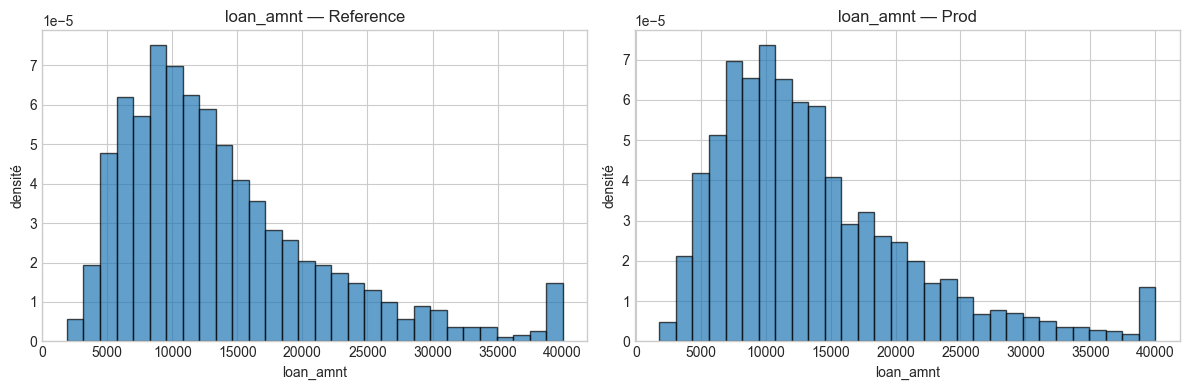

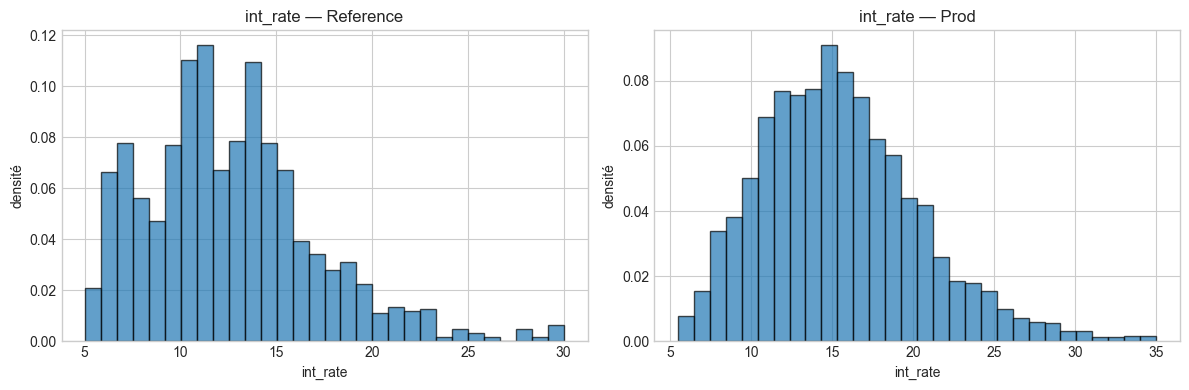

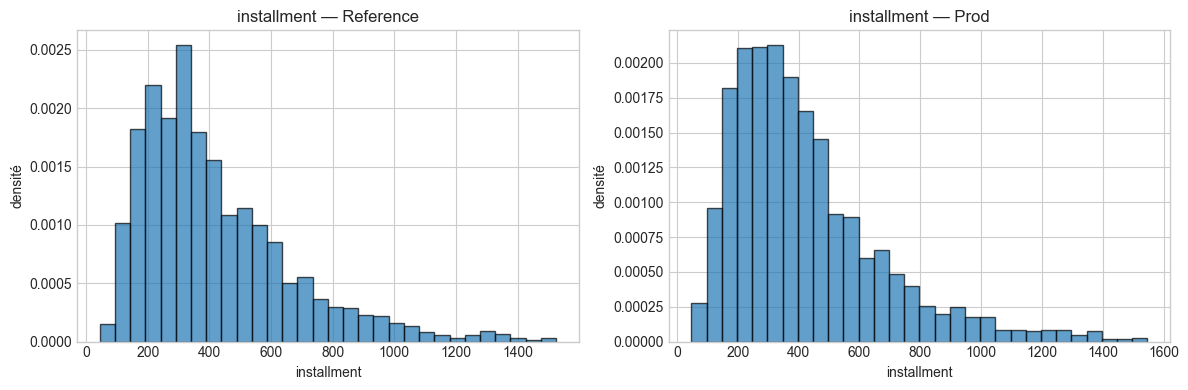

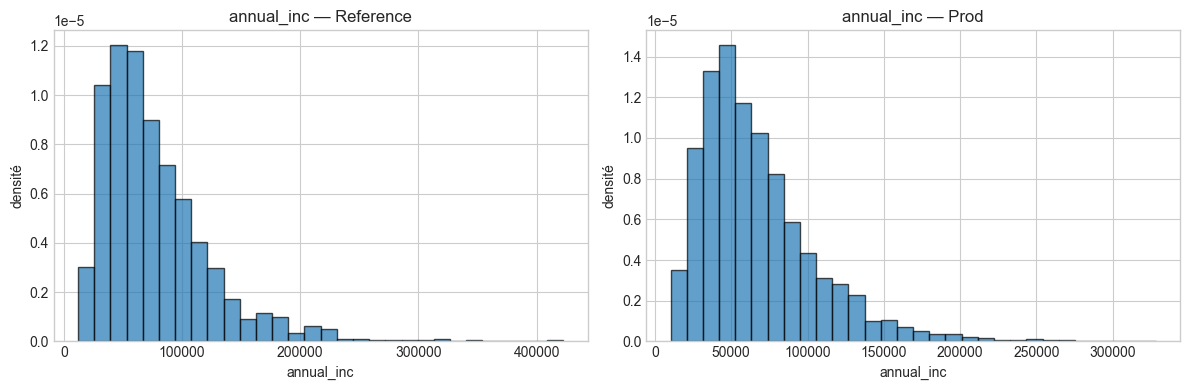

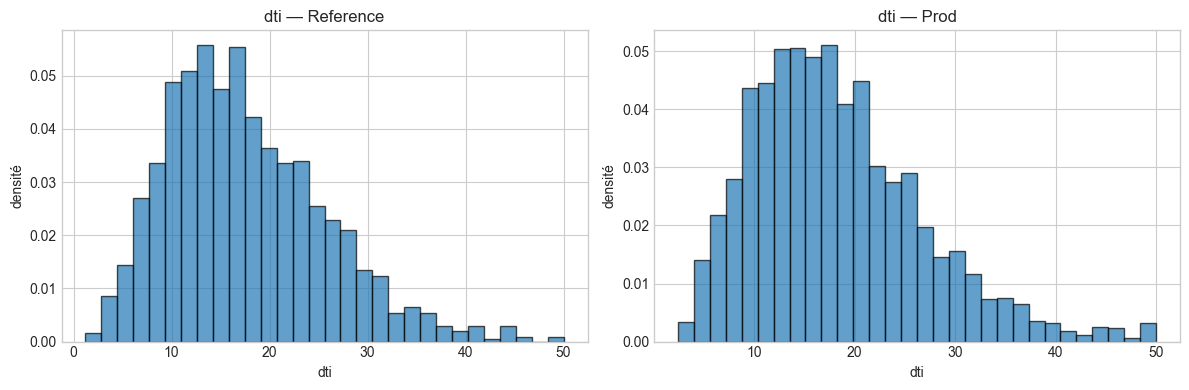

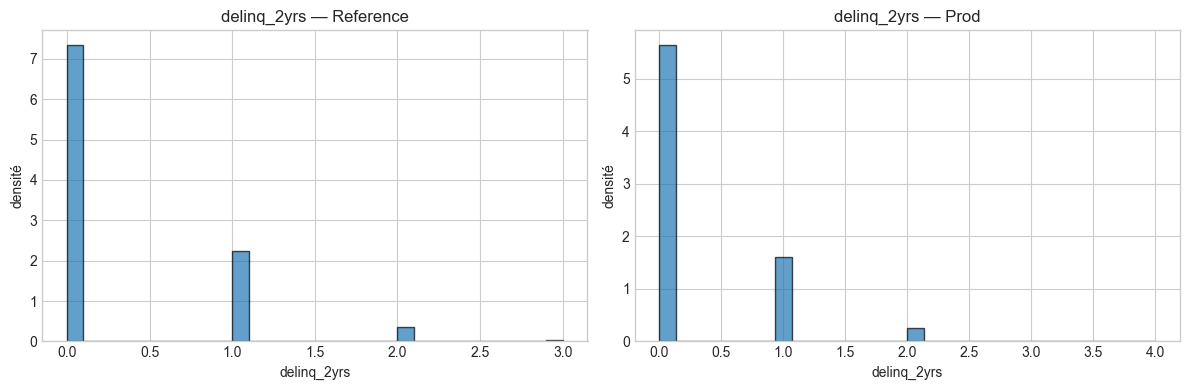

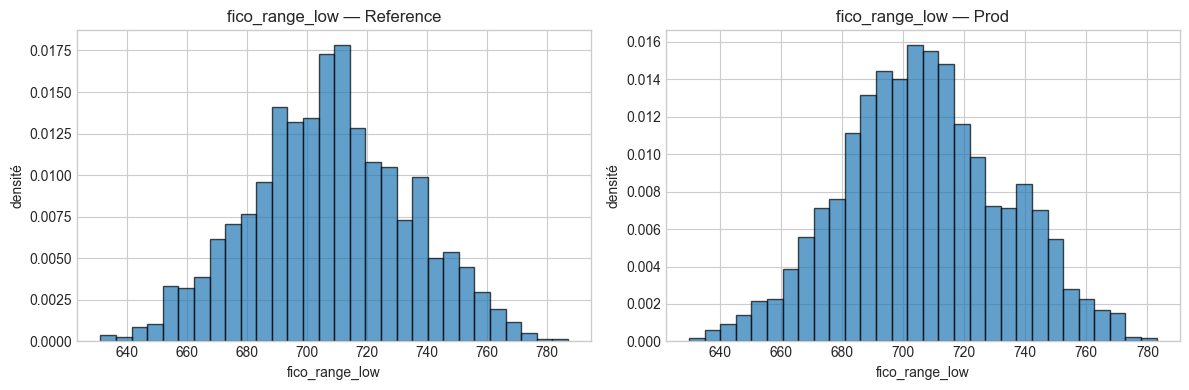

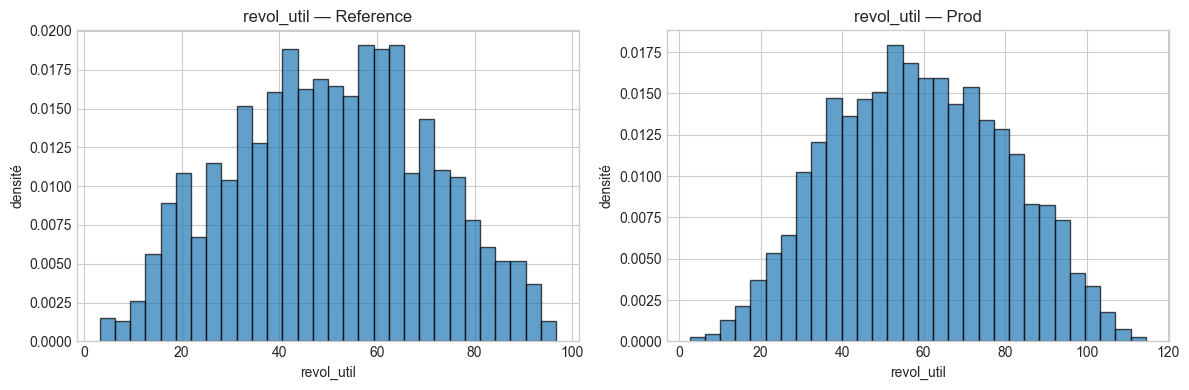

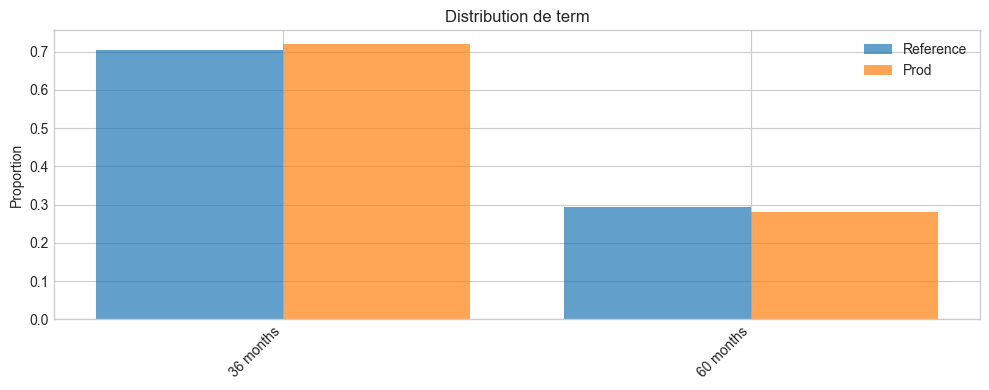

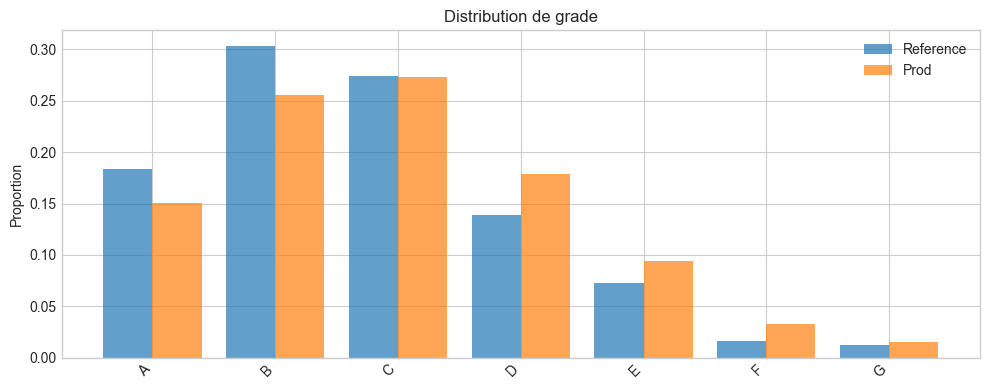

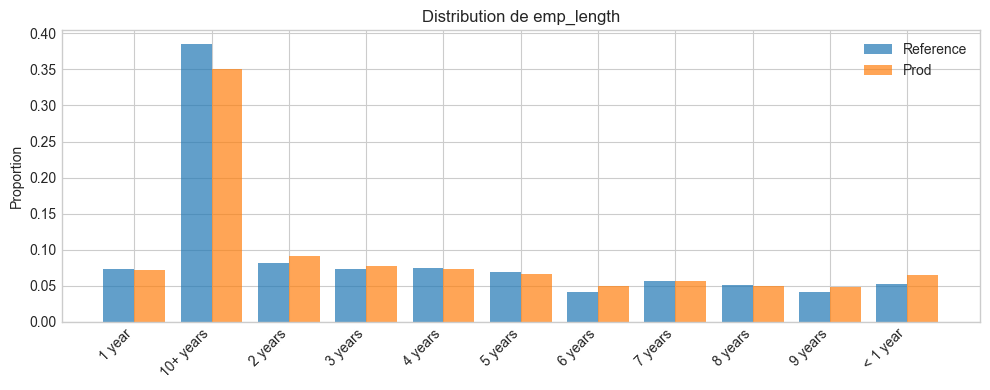

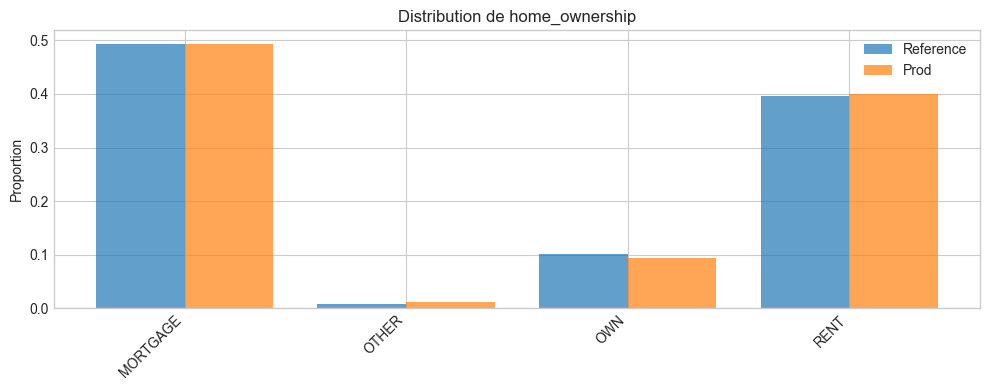

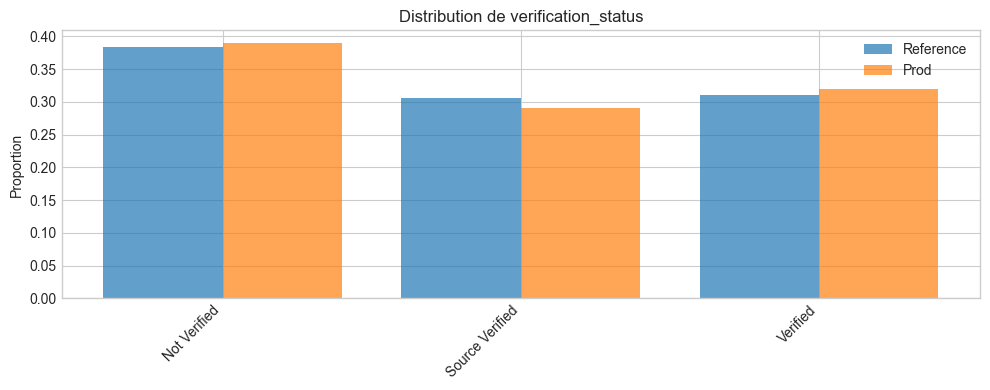

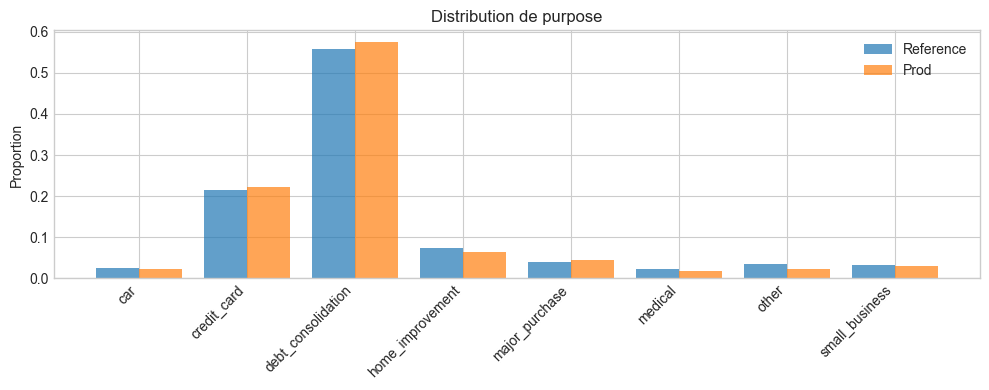

       feature     ref_mean    prod_mean      ref_std     prod_std  ref_p50  prod_p50
     loan_amnt 13828.400000 13800.066667  7761.012970  7680.036088 11900.00 11900.000
      int_rate    12.613413    15.499213     4.472691     4.924187    12.01    15.085
   installment   417.861027   421.532343   246.171244   249.185777   354.45   362.560
    annual_inc 76938.400000 67156.463667 45641.435917 39129.824874 65950.00 57935.500
           dti    17.564213    18.201200     8.047515     8.490802    16.48    16.945
   delinq_2yrs     0.312000     0.282333     0.562317     0.524131     0.00     0.000
fico_range_low   707.366000   706.686333    26.370962    26.631667   707.00   706.000
    revol_util    50.573986    58.962149    20.012892    21.161730    50.90    58.400


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

root = Path.cwd().resolve().parent
ref = pd.read_csv(root / "data" / "reference_set.csv")
prod = pd.read_csv(root / "data" / "prod_3months.csv")

# On exclut la cible, et le timestamp de production s'il est présent.
exclude_cols = {"loan_status", "timestamp"}
feature_cols = [c for c in ref.columns if c not in exclude_cols and c in prod.columns]

numeric_cols = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(ref[c]) and pd.api.types.is_numeric_dtype(prod[c])
]
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

print(f"Features numériques ({len(numeric_cols)}): {numeric_cols}")
print(f"Features catégorielles ({len(categorical_cols)}): {categorical_cols}")

# --- 1) Variables numériques : histogrammes superposés ---
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, name, df in zip(axes, ["Reference", "Prod"], [ref, prod]):
        s = df[col].dropna()
        ax.hist(s, bins=30, density=True, alpha=0.7, edgecolor="black")
        ax.set_title(f"{col} — {name}")
        ax.set_xlabel(col)
        ax.set_ylabel("densité")
    plt.tight_layout()
    plt.show()

# --- 2) Variables catégorielles : proportions par modalité ---
for col in categorical_cols:
    ref_counts = ref[col].dropna().astype(str).value_counts(normalize=True)
    prod_counts = prod[col].dropna().astype(str).value_counts(normalize=True)
    all_levels = sorted(set(ref_counts.index) | set(prod_counts.index), key=lambda x: str(x))
    ref_prop = ref_counts.reindex(all_levels, fill_value=0)
    prod_prop = prod_counts.reindex(all_levels, fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(all_levels))
    ax.bar(x, ref_prop.values, width=0.4, alpha=0.7, label="Reference")
    ax.bar([i + 0.4 for i in x], prod_prop.values, width=0.4, alpha=0.7, label="Prod")
    ax.set_xticks([i + 0.2 for i in x])
    ax.set_xticklabels(all_levels, rotation=45, ha="right")
    ax.set_title(f"Distribution de {col}")
    ax.set_ylabel("Proportion")
    ax.legend()
    plt.tight_layout()
    plt.show()

# --- 3) Comparaison concise des stats descriptives ---
summary = []
for col in numeric_cols:
    summary.append({
        "feature": col,
        "ref_mean": ref[col].mean(),
        "prod_mean": prod[col].mean(),
        "ref_std": ref[col].std(),
        "prod_std": prod[col].std(),
        "ref_p50": ref[col].median(),
        "prod_p50": prod[col].median(),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


D’après le visuel, les colonnes qui dérivent le plus:
int_rate
installment
revol_util
annual_inc


## 2. Détection statistique — PSI · KS · Chi²

In [ ]:
# TODO


## 3. Calibration en exploitation

In [ ]:
# TODO


## 4. Performance dans le temps

In [ ]:
# TODO


## 5. Diagnostic & recommandation

In [ ]:
# TODO
